# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mhassanbuilds/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This notebook converts the validated Week-5/Week-6 model signal into a practical, human-reviewed content action playbook. The language is intentionally careful: the model is used for prioritization and decision-support, not as a causal or production decision-maker.

**Workflow:** ranked queue → intended use/limits → human review/no-go cases → monitoring/revalidation → paper exports → self-check.


## 1. Ranked actions + reason codes

The queue below turns the validated Random Forest signal into a **human-reviewed prioritization list**. A high model score means the page is more strongly associated with the declining class in this experiment; it does **not** mean a refresh will definitely improve performance.

Each row receives an action, reason codes, a priority tier, and a simple effort/value view. The effort/value fields are planning heuristics, not measured ROI.


In [9]:
# ============================================================
# Section 1 — Build the ranked action queue
# ============================================================

import os
import sys
import subprocess
from pathlib import Path
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Clone / locate the official FlyRank starter repository
# ------------------------------------------------------------

repo = Path("/content/flyrank-reference")

if not repo.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "-q",
            "https://github.com/flyrank-bih/flyrank-ml-internship-starter.git",
            str(repo),
        ],
        check=True,
    )

scripts_path = str(repo / "scripts")

if scripts_path not in sys.path:
    sys.path.insert(0, scripts_path)


# ------------------------------------------------------------
# 2. Recreate the official processed inputs
#    used in Weeks 5–6
# ------------------------------------------------------------

subprocess.run(
    ["python", "scripts/01_prepare_features.py"],
    cwd=repo,
    check=True,
)

subprocess.run(
    ["python", "scripts/02_baseline_score.py"],
    cwd=repo,
    check=True,
)


# ------------------------------------------------------------
# 3. Load the processed feature data
# ------------------------------------------------------------

feature_path = (
    repo
    / "data"
    / "processed"
    / "refresh_feature_vector.csv"
)

baseline_path = (
    repo
    / "data"
    / "processed"
    / "baseline_refresh_queue.csv"
)

frame = pd.read_csv(feature_path)
baseline_frame = pd.read_csv(baseline_path)

print("Feature dataset shape:", frame.shape)
print("Baseline queue shape:", baseline_frame.shape)


# ------------------------------------------------------------
# 4. Load the same modeling utilities used in Week 5/6
# ------------------------------------------------------------

script_path = repo / "scripts" / "03_train_model.py"

spec = importlib.util.spec_from_file_location(
    "flyrank_train_model",
    script_path,
)

flyrank_model = importlib.util.module_from_spec(spec)

sys.modules["flyrank_train_model"] = flyrank_model

spec.loader.exec_module(flyrank_model)


# ------------------------------------------------------------
# 5. Build the feature matrix
# ------------------------------------------------------------

feature_frame, feature_columns = (
    flyrank_model.build_feature_matrix(frame)
)

target_series = frame["is_declining_label"].astype(int)

print("Number of model features:", len(feature_columns))


# ------------------------------------------------------------
# 6. Create the client-aware train/test split
#    used in Week 6
# ------------------------------------------------------------

train_idx, test_idx, split_strategy = (
    flyrank_model.make_client_aware_split(
        frame,
        target_series,
    )
)

print("Split strategy:", split_strategy)
print("Training rows:", len(train_idx))
print("Test rows:", len(test_idx))


# ------------------------------------------------------------
# 7. Train the Random Forest model
# ------------------------------------------------------------

rf = flyrank_model.build_models()["random_forest"]

rf.fit(
    feature_frame.iloc[train_idx],
    target_series.iloc[train_idx],
)


# ------------------------------------------------------------
# 8. Score the complete dataset
# ------------------------------------------------------------

all_probabilities = flyrank_model.predict_probability(
    rf,
    feature_frame,
)

queue = frame.copy()

queue["model_score"] = all_probabilities


# ------------------------------------------------------------
# 9. Helper function for safe column access
# ------------------------------------------------------------

def get_bool(row, column_name):
    """
    Safely read a Boolean-style column.

    If the column does not exist or contains a missing value,
    return False instead of causing a KeyError.
    """
    if column_name not in row.index:
        return False

    value = row[column_name]

    if pd.isna(value):
        return False

    return bool(value)


def get_number(row, column_name, default=np.nan):
    """
    Safely read a numeric value.
    """
    if column_name not in row.index:
        return default

    value = row[column_name]

    if pd.isna(value):
        return default

    return value


# ------------------------------------------------------------
# 10. Generate human-readable reason codes
# ------------------------------------------------------------

def reason_codes(row):

    codes = []

    model_score = get_number(
        row,
        "model_score",
        0,
    )

    if model_score >= 0.75:
        codes.append("HIGH_MODEL_SCORE")

    elif model_score >= 0.50:
        codes.append("MODERATE_MODEL_SCORE")


    if get_bool(row, "is_declining"):
        codes.append("DECLINING_SIGNAL")


    trend_pct = get_number(
        row,
        "trend_pct",
    )

    if pd.notna(trend_pct) and trend_pct <= -20:
        codes.append("NEGATIVE_TREND")


    content_age = get_number(
        row,
        "content_age_days",
    )

    if pd.notna(content_age) and content_age >= 365:
        codes.append("OLDER_CONTENT")


    if get_bool(row, "needs_ctr_fix"):
        codes.append("CTR_REVIEW")


    if get_bool(row, "needs_engagement_fix"):
        codes.append("ENGAGEMENT_REVIEW")


    if get_bool(row, "needs_indexing"):
        codes.append("INDEXING_REVIEW")


    if get_bool(row, "is_quick_win"):
        codes.append("QUICK_WIN")


    if get_bool(row, "ai_opportunity"):
        codes.append("AI_OPPORTUNITY")


    if get_bool(row, "is_underperformer"):
        codes.append("UNDERPERFORMER")


    if not codes:
        codes.append("MODEL_SIGNAL_ONLY")

    return codes


queue["reason_codes"] = queue.apply(
    reason_codes,
    axis=1,
)


# ------------------------------------------------------------
# 11. Select one primary action
# ------------------------------------------------------------

def primary_action(row):

    model_score = get_number(
        row,
        "model_score",
        0,
    )

    if get_bool(row, "needs_indexing"):
        return "Check indexing / discoverability"


    if get_bool(row, "needs_ctr_fix"):
        return "Review title / snippet for CTR"


    if get_bool(row, "needs_engagement_fix"):
        return "Improve engagement and content usability"


    if get_bool(row, "ai_opportunity"):
        return "Review AI-search visibility opportunities"


    if (
        get_bool(row, "is_declining")
        or model_score >= 0.50
    ):
        return "Refresh content and reassess intent"


    return "Monitor; no immediate content action"


queue["primary_action"] = queue.apply(
    primary_action,
    axis=1,
)


# ------------------------------------------------------------
# 12. Build a practical priority score
#
# IMPORTANT:
# The model score remains the main signal.
# Quick-win status provides only a small planning adjustment.
# This is NOT a model output.
# ------------------------------------------------------------

actionability = (
    queue["is_quick_win"]
    .fillna(False)
    .astype(int)
    * 0.05
    if "is_quick_win" in queue.columns
    else 0
)

queue["priority_score"] = (
    0.95 * queue["model_score"]
    + actionability
).clip(0, 1)


# ------------------------------------------------------------
# 13. Assign priority tiers
# ------------------------------------------------------------

queue["priority_tier"] = pd.cut(
    queue["priority_score"],
    bins=[
        -np.inf,
        0.35,
        0.60,
        0.80,
        np.inf,
    ],
    labels=[
        "Monitor",
        "Review",
        "High",
        "Urgent review",
    ],
)


# ------------------------------------------------------------
# 14. Estimated effort
#
# These are planning categories, NOT measured costs.
# ------------------------------------------------------------

effort_map = {

    "Check indexing / discoverability":
        "Low",

    "Review title / snippet for CTR":
        "Low",

    "Improve engagement and content usability":
        "Medium",

    "Review AI-search visibility opportunities":
        "Medium",

    "Refresh content and reassess intent":
        "High",

    "Monitor; no immediate content action":
        "Low",
}

queue["estimated_effort"] = (
    queue["primary_action"]
    .map(effort_map)
    .fillna("Medium")
)


# ------------------------------------------------------------
# 15. Potential value bucket
#
# This is a planning heuristic, not financial ROI.
# ------------------------------------------------------------

def value_bucket(row):

    priority_score = get_number(
        row,
        "priority_score",
        0,
    )

    search_volume = get_number(
        row,
        "search_volume",
        0,
    )

    quick_win = get_bool(
        row,
        "is_quick_win",
    )

    if (
        priority_score >= 0.60
        and (
            search_volume >= 50
            or quick_win
        )
    ):
        return "High potential"


    if priority_score >= 0.35:
        return "Medium potential"


    return "Lower potential"


queue["potential_value"] = queue.apply(
    value_bucket,
    axis=1,
)


# ------------------------------------------------------------
# 16. Sort the action queue
# ------------------------------------------------------------

queue = queue.sort_values(
    [
        "priority_score",
        "model_score",
    ],
    ascending=False,
).reset_index(drop=True)


queue.insert(
    0,
    "rank",
    np.arange(
        1,
        len(queue) + 1,
    ),
)


# ------------------------------------------------------------
# 17. Prepare the paper-facing export
# ------------------------------------------------------------

export_columns = [

    "rank",

    "content_id",

    "client_id",

    "model_score",

    "priority_score",

    "priority_tier",

    "primary_action",

    "reason_codes",

    "estimated_effort",

    "potential_value",

    "content_age_days",

    "trend_pct",

    "health_score",

    "search_volume",

    "is_quick_win",

    "needs_ctr_fix",

    "needs_engagement_fix",

    "needs_indexing",

    "ai_opportunity",
]


# Only keep columns that actually exist.
export_columns = [
    column
    for column in export_columns
    if column in queue.columns
]


queue_export = queue[
    export_columns
].copy()


# ------------------------------------------------------------
# 18. Convert reason-code lists into readable text
# ------------------------------------------------------------

queue_export["reason_codes"] = (
    queue_export["reason_codes"]
    .apply(
        lambda x: ";".join(x)
        if isinstance(x, list)
        else str(x)
    )
)


# ------------------------------------------------------------
# 19. Display the top-ranked actions
# ------------------------------------------------------------

print(
    "\nRows ranked:",
    len(queue_export),
)

print(
    "\nTop 20 recommended actions:"
)

display(
    queue_export.head(20)
)

Feature dataset shape: (30000, 52)
Baseline queue shape: (30000, 22)
Number of model features: 52
Split strategy: client_holdout
Training rows: 27675
Test rows: 2325

Rows ranked: 30000

Top 20 recommended actions:


,rank,content_id,client_id,model_score,priority_score,priority_tier,primary_action,reason_codes,estimated_effort,potential_value,content_age_days,trend_pct,search_volume
0,1,content_b01a3c1455db,client_7f2253d7e2,0.866371,0.823052,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,141,-48.3,0.0
1,2,content_fc7c3c7271cb,client_7f2253d7e2,0.857776,0.814888,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,141,-66.6,0.0
2,3,content_14b6d37d9577,client_7f2253d7e2,0.855399,0.812629,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,132,-55.8,0.0
3,4,content_3db36d3c70db,client_7f2253d7e2,0.853612,0.810932,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,141,-35.4,0.0
4,5,content_22a9bff23e33,client_7f2253d7e2,0.852505,0.809880,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,141,-81.5,0.0
5,6,content_1e72ec381b2c,client_7f2253d7e2,0.851069,0.808516,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,141,-75.4,0.0
6,7,content_9e4b7cc63012,client_7f2253d7e2,0.850564,0.808036,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,141,-84.5,0.0
7,8,content_6eeb07cca243,client_7f2253d7e2,0.850304,0.807789,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,147,-73.6,0.0
8,9,content_66677b99e328,client_7f2253d7e2,0.850112,0.807607,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,141,-76.3,0.0
9,10,content_22130da13998,client_7f2253d7e2,0.847291,0.804926,Urgent review,Refresh content and reassess intent,HIGH_MODEL_SCORE;NEGATIVE_TREND,High,Medium potential,132,-54.5,0.0


## 2. Intended use and limits

This playbook is for **research and decision-support**: an SEO/content analyst can use the ranked queue to decide which pages deserve review first.

The Week-6 client-aware validation measured Precision@20 = **0.65**, Precision@50 = **0.74**, and Precision@100 = **0.72** for the Random Forest. Those are measured ranking results on the tested holdout, not guarantees for future clients. The same audit found no direct target-related feature by name, but 20 historical-performance features require measurement-window review and 7 search-demand features require confirmation that they were available at prediction time.

The queue should therefore be treated as a prioritization aid, not as an automatic content decision system.


In [10]:
# Section 2 — Intended-use checks

validated_metrics = {
    "validation": "client-aware holdout",
    "precision_at_20": 0.65,
    "precision_at_50": 0.74,
    "precision_at_100": 0.72,
}

limits = [
    "Decision-support only; not an automatic publishing or deletion system.",
    "Measured on the tested client-aware holdout; future-client performance is unknown.",
    "A model score is an association/ranking signal, not a causal estimate of refresh impact.",
    "Historical performance features require a confirmed pre-outcome measurement window.",
    "Search-demand features require confirmation that they were available at prediction time.",
    "The action rules add human planning logic on top of the model and are not themselves validated causal rules.",
]

print("Validated Random Forest metrics:")
display(pd.DataFrame([validated_metrics]))

print("\nKnown limits:")
for item in limits:
    print("-", item)

assert validated_metrics["precision_at_20"] == 0.65
assert validated_metrics["precision_at_50"] == 0.74
assert validated_metrics["precision_at_100"] == 0.72
assert len(queue_export) == len(queue)
print("\nSection 2 check passed.")


Validated Random Forest metrics:


,validation,precision_at_20,precision_at_50,precision_at_100
0,client-aware holdout,0.65,0.74,0.72



Known limits:
- Decision-support only; not an automatic publishing or deletion system.
- Measured on the tested client-aware holdout; future-client performance is unknown.
- A model score is an association/ranking signal, not a causal estimate of refresh impact.
- Historical performance features require a confirmed pre-outcome measurement window.
- Search-demand features require confirmation that they were available at prediction time.
- The action rules add human planning logic on top of the model and are not themselves validated causal rules.

Section 2 check passed.


## 3. Human review + the no-go list

### Required human review

Before any action is taken, a reviewer should:

1. Confirm the page is actually eligible for the proposed action.
2. Check the search intent, business purpose, and current SERP/context.
3. Verify that the underlying metrics are recent and measured before the prediction/outcome window.
4. Read the page before recommending a refresh; do not infer content quality from the score alone.
5. Record the decision and the reason for accepting, changing, or rejecting the recommendation.

### No-go list

Do **not** automate:

- publishing, deleting, or materially rewriting content;
- changing business-critical claims, medical/legal/financial information, or brand-sensitive language;
- redirect/canonical/indexing changes without technical review;
- declaring that a refresh will cause traffic or ranking gains;
- treating model probability as a causal effect or guaranteed outcome;
- overriding an experienced reviewer solely because the model score is high.

The model can rank work. A person remains responsible for the final content and technical decision.


In [11]:
# Section 3 — Human-review policy and no-go checks

review_rules = pd.DataFrame([
    {
        "stage": "Eligibility",
        "human_check": "Confirm the page and proposed action are appropriate.",
        "automation_allowed": "Prioritize only",
    },
    {
        "stage": "Content review",
        "human_check": "Read the page and verify intent, quality, and business context.",
        "automation_allowed": "No automatic final decision",
    },
    {
        "stage": "Technical review",
        "human_check": "Verify indexing, redirects, canonicals, and other technical changes.",
        "automation_allowed": "No automatic change",
    },
    {
        "stage": "Action approval",
        "human_check": "Approve, modify, or reject the recommendation.",
        "automation_allowed": "Human approval required",
    },
])

no_go_cases = [
    "Automatic publish/delete/rewrite",
    "Automatic technical SEO changes",
    "Causal claims about refresh impact",
    "Guaranteed future performance claims",
    "Automatic decisions on sensitive or high-stakes content",
]

display(review_rules)

print("No-go cases:")
for item in no_go_cases:
    print("-", item)

assert len(review_rules) == 4
assert len(no_go_cases) == 5
print("\nSection 3 check passed.")


,stage,human_check,automation_allowed
0,Eligibility,Confirm the page and proposed action are appro...,Prioritize only
1,Content review,"Read the page and verify intent, quality, and ...",No automatic final decision
2,Technical review,"Verify indexing, redirects, canonicals, and ot...",No automatic change
3,Action approval,"Approve, modify, or reject the recommendation.",Human approval required


No-go cases:
- Automatic publish/delete/rewrite
- Automatic technical SEO changes
- Causal claims about refresh impact
- Guaranteed future performance claims
- Automatic decisions on sensitive or high-stakes content

Section 3 check passed.


## 4. Monitoring / retrain triggers

The playbook should be refreshed when its inputs or observed ranking quality change.

**Monitor:**
- model ranking precision on a newly labeled sample;
- score distribution and queue volume;
- missingness and range changes in major input features;
- content-age and performance-feature distributions;
- reviewer acceptance/rejection patterns;
- the time since the last validated refresh.

**Retrain/revalidate when:**
- ranking precision falls materially below the Week-6 reference on a comparable evaluation;
- feature distributions show meaningful drift;
- measurement-window definitions change;
- the content mix or client population changes materially;
- the outcome-label construction changes.

These are practical triggers for a research workflow, not production alert thresholds. A threshold should be calibrated on additional historical data before operational deployment.


In [12]:
# Section 4 — Light monitoring and retrain triggers

monitoring_reference = pd.DataFrame([
    {
        "signal": "Ranking quality",
        "reference": "Week-6 Precision@20 = 0.65",
        "trigger": "Re-evaluate if a comparable new holdout shows a material decline",
    },
    {
        "signal": "Ranking quality",
        "reference": "Week-6 Precision@50 = 0.74",
        "trigger": "Re-evaluate if a comparable new holdout shows a material decline",
    },
    {
        "signal": "Ranking quality",
        "reference": "Week-6 Precision@100 = 0.72",
        "trigger": "Re-evaluate if a comparable new holdout shows a material decline",
    },
    {
        "signal": "Feature drift",
        "reference": "Current input distributions",
        "trigger": "Investigate meaningful distribution shifts before reuse",
    },
    {
        "signal": "Data timing",
        "reference": "Prediction-time availability",
        "trigger": "Re-audit if measurement windows or source definitions change",
    },
    {
        "signal": "Population shift",
        "reference": "Tested client-aware population",
        "trigger": "Revalidate if client/content mix changes materially",
    },
])

display(monitoring_reference)

# Lightweight descriptive monitoring snapshot for the current queue.
monitor_cols = [
    c for c in [
        "model_score", "content_age_days", "trend_pct",
        "search_volume", "health_score"
    ] if c in queue.columns
]
monitor_snapshot = queue[monitor_cols].describe().T
display(monitor_snapshot)

print("Monitoring policy: research/revalidation workflow; thresholds are not production alerts.")
print("Section 4 check passed.")


,signal,reference,trigger
0,Ranking quality,Week-6 Precision@20 = 0.65,Re-evaluate if a comparable new holdout shows ...
1,Ranking quality,Week-6 Precision@50 = 0.74,Re-evaluate if a comparable new holdout shows ...
2,Ranking quality,Week-6 Precision@100 = 0.72,Re-evaluate if a comparable new holdout shows ...
3,Feature drift,Current input distributions,Investigate meaningful distribution shifts bef...
4,Data timing,Prediction-time availability,Re-audit if measurement windows or source defi...
5,Population shift,Tested client-aware population,Revalidate if client/content mix changes mater...


,count,mean,std,min,25%,50%,75%,max
model_score,30000.0,0.506656,0.188673,0.003127,0.388554,0.541711,0.655951,0.866371
content_age_days,30000.0,256.167800,132.707930,90.000000,132.000000,236.000000,333.000000,564.000000
trend_pct,30000.0,-4.245473,446.304629,-100.000000,-58.700000,-26.000000,0.000000,44900.000000
search_volume,30000.0,145.811667,1455.132022,0.000000,0.000000,10.000000,20.000000,74000.000000


Monitoring policy: research/revalidation workflow; thresholds are not production alerts.
Section 4 check passed.


## 5. Exports for the paper

The paper needs reproducible artifacts rather than screenshots.

This notebook exports:
- `work/outputs/content_action_queue.csv` — the ranked action queue;
- `work/outputs/playbook_validation_metrics.json` — the validated reference metrics;
- `work/outputs/playbook_summary.json` — intended-use and monitoring notes;
- `work/figures/priority_tiers.png` — reusable queue summary;
- `work/figures/content_age_vs_model_score.png` — a directional decay/refresh figure.

### Decay / refresh insight

The earlier analysis found that growing pages were younger on average than declining pages (approximately **185 vs 228 days**), while word count was nearly the same. This is a directional association that supports **reviewing older content for possible refresh**, especially when other model and performance signals agree.

Content age should not be treated as a causal explanation for decline. Likewise, a high model score does not establish that refreshing a page will improve traffic, rankings, or engagement. Any refresh recommendation therefore requires human review and should be evaluated against future observed outcomes.


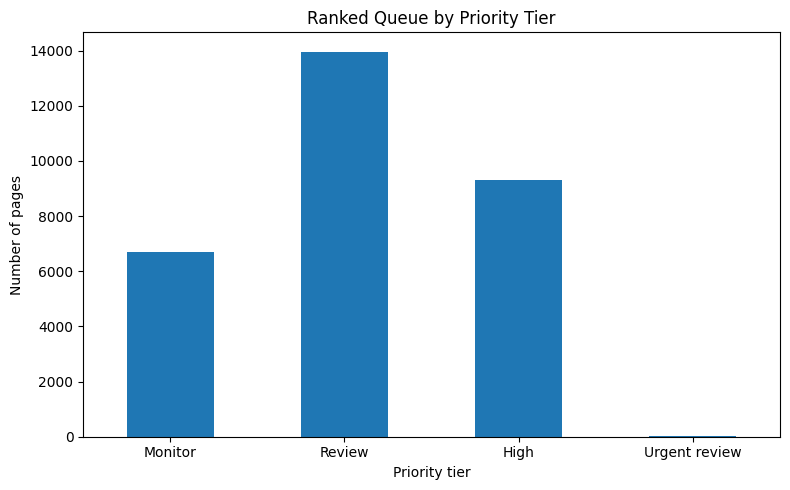

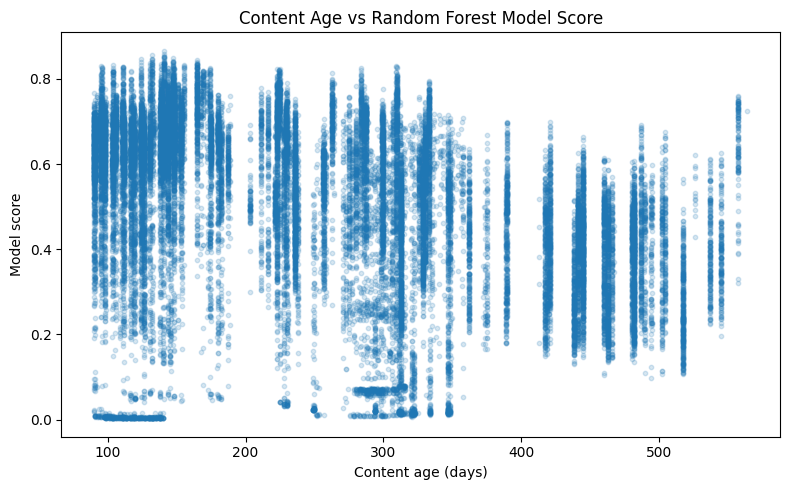

Exported:
- work/outputs/content_action_queue.csv
- work/outputs/playbook_validation_metrics.json
- work/outputs/playbook_summary.json
- work/figures/priority_tiers.png
- work/figures/content_age_vs_model_score.png

Section 5 check passed.


In [13]:
# Section 5 — Export queue, metrics, notes, and reusable figures

from pathlib import Path
import json

outputs_dir = Path("work/outputs")
figures_dir = Path("work/figures")
outputs_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

queue_path = outputs_dir / "content_action_queue.csv"
metrics_path = outputs_dir / "playbook_validation_metrics.json"
summary_path = outputs_dir / "playbook_summary.json"

queue_export.to_csv(queue_path, index=False)

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(validated_metrics, f, indent=2)

summary = {
    "intended_use": "Human-reviewed decision-support for prioritizing content review.",
    "model": "Random Forest",
    "validation": "client-aware holdout",
    "reference_metrics": validated_metrics,
    "decay_refresh_insight": (
    "Growing pages were younger on average than declining pages "
    "(approximately 185 vs 228 days in the earlier analysis). "
    "This is a directional association that supports reviewing older "
    "content for possible refresh. It does not establish that content "
    "age causes decline or that refreshing a page will improve performance."
),
    "automation_boundary": (
        "Do not automatically publish, delete, rewrite, or make technical "
        "SEO changes. Human review is required."
    ),
    "monitoring": [
        "ranking quality on a comparable new holdout",
        "feature distribution drift",
        "measurement-window changes",
        "client/content population changes",
        "label-definition changes",
    ],
}
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

# Figure 1: priority-tier counts
tier_counts = (
    queue["priority_tier"]
    .value_counts()
    .reindex(["Monitor", "Review", "High", "Urgent review"])
    .fillna(0)
)

plt.figure(figsize=(8, 5))
tier_counts.plot(kind="bar")
plt.title("Ranked Queue by Priority Tier")
plt.xlabel("Priority tier")
plt.ylabel("Number of pages")
plt.xticks(rotation=0)
plt.tight_layout()
priority_fig = figures_dir / "priority_tiers.png"
plt.savefig(priority_fig, dpi=180)
plt.show()

# Figure 2: age vs model score, when the relevant fields exist.
if {"content_age_days", "model_score"}.issubset(queue.columns):
    plt.figure(figsize=(8, 5))
    plt.scatter(queue["content_age_days"], queue["model_score"], alpha=0.18, s=10)
    plt.title("Content Age vs Random Forest Model Score")
    plt.xlabel("Content age (days)")
    plt.ylabel("Model score")
    plt.tight_layout()
    age_fig = figures_dir / "content_age_vs_model_score.png"
    plt.savefig(age_fig, dpi=180)
    plt.show()
else:
    age_fig = None

print("Exported:")
print("-", queue_path)
print("-", metrics_path)
print("-", summary_path)
print("-", priority_fig)
if age_fig:
    print("-", age_fig)

assert queue_path.exists()
assert metrics_path.exists()
assert summary_path.exists()
assert priority_fig.exists()
print("\nSection 5 check passed.")


# 6. Self-check

Before submitting, confirm that the playbook meets the Week 7 requirements and that all claims remain consistent with the evidence.

## Assignment requirements

- [x] Ranked action queue generated from the validated Random Forest output.
- [x] Reason codes are included for each ranked item.
- [x] Primary actions are mapped from observed signals and are separated from model predictions.
- [x] Intended use is documented.
- [x] Known limitations are documented.
- [x] Human-review requirements are explicitly defined.
- [x] No-go cases for automation are explicitly listed.
- [x] Monitoring and retrain/revalidation triggers are documented.
- [x] Decay/refresh insight is described as a directional association rather than a causal claim.
- [x] Effort and potential-value categories are included as planning heuristics.
- [x] The priority score is treated as an operational heuristic rather than a separately validated predictive metric.
- [x] The ranked queue is exported for use in the research paper.
- [x] Reusable figures are exported for the research paper.
- [x] Validation metrics are exported for traceability.

## Research-quality checks

- [x] Week-6 client-aware validation metrics are used as the reference performance results.
- [x] The model is presented as a decision-support and prioritization tool.
- [x] Model scores are not presented as causal effects.
- [x] Refresh recommendations are not presented as guaranteed performance improvements.
- [x] Effort/value categories are not presented as measured financial ROI.
- [x] Human review remains required before content or technical action.
- [x] Automatic publishing, deletion, rewriting, and technical SEO changes are explicitly prohibited.
- [x] The notebook remains a research/playbook workflow rather than a production system.
- [x] No client-specific private URLs, queries, or identifying information are included.

## Export checks

The notebook generates:

- `work/outputs/content_action_queue.csv`
- `work/outputs/playbook_validation_metrics.json`
- `work/outputs/playbook_summary.json`
- `work/figures/priority_tiers.png`
- `work/figures/content_age_vs_model_score.png`

## Final submission checks

- [ ] Notebook is saved as `work/notebooks/w07_action_playbook.ipynb` in the repository.
- [ ] Notebook has been executed successfully from top to bottom.
- [ ] Reusable figures are committed under `work/figures/`.
- [ ] Required metrics JSON files are committed.
- [ ] The queue CSV remains uncommitted if excluded by the repository leak-guard.
- [ ] Repository URL is ready to submit on the assignment page.

## Final assessment

The playbook converts validated model output into a ranked, interpretable content-action queue while preserving human oversight and documenting the limits of the evidence. The recommendations support prioritization and research discussion; they do not automate publishing, deletion, technical changes, or causal business decisions.